# Practical 7 — Random Forest, OOB Error, Bagging & Feature Subsampling

**Dataset:** Iris Dataset

### Objectives
- Train and evaluate a Decision Tree baseline.
- Train a Random Forest classifier.
- Calculate Out-of-Bag (OOB) Score and OOB Error.
- Study OOB Error versus number of trees.
- Study feature subsampling using `max_features`.
- Implement manual bootstrap bagging.
- Implement `BaggingClassifier`.
- Calculate permutation feature importance.
- Compare the models.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.inspection import permutation_importance
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Load the Iris Dataset

In [7]:
# Load Iris dataset
iris = datasets.load_iris()

X = iris.data
y = iris.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


## 2. Explore the Dataset

In [8]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["target"].value_counts().sort_index())

print("\nTarget names:")
for i, name in enumerate(iris.target_names):
    print(f"{i} -> {name}")

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Target distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64

Target names:
0 -> setosa
1 -> versicolor
2 -> virginica


## 3. Separate Features and Target

In [9]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

## 4. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## 5. Single Decision Tree Baseline

In [11]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9333333333333333


In [12]:
print("Decision Tree Classification Report:")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=iris.target_names
))

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Decision Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


## 6. Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    bootstrap=True
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9


## 7. Out-of-Bag (OOB) Score and OOB Error

**OOB Error = 1 − OOB Score**

OOB samples are training samples that are not selected in the bootstrap sample for a particular tree.

In [14]:
oob_score = rf.oob_score_
oob_error = 1 - oob_score

print("OOB Score:", oob_score)
print("OOB Error:", oob_error)

OOB Score: 0.9416666666666667
OOB Error: 0.05833333333333335


## 8. OOB Error vs Number of Trees

In [15]:
n_estimators_list = [1, 5, 10, 20, 50, 100, 150, 200]
oob_errors = []

for n in n_estimators_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        oob_score=True,
        bootstrap=True
    )

    rf_temp.fit(X_train, y_train)
    oob_errors.append(1 - rf_temp.oob_score_)

oob_results = pd.DataFrame({
    "Number of Trees": n_estimators_list,
    "OOB Error": oob_errors
})

display(oob_results)

/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,Number of Trees,OOB Error
0,1,0.433333
1,5,0.108333
2,10,0.050000
3,20,0.058333
4,50,0.058333
5,100,0.058333
6,150,0.050000
7,200,0.050000


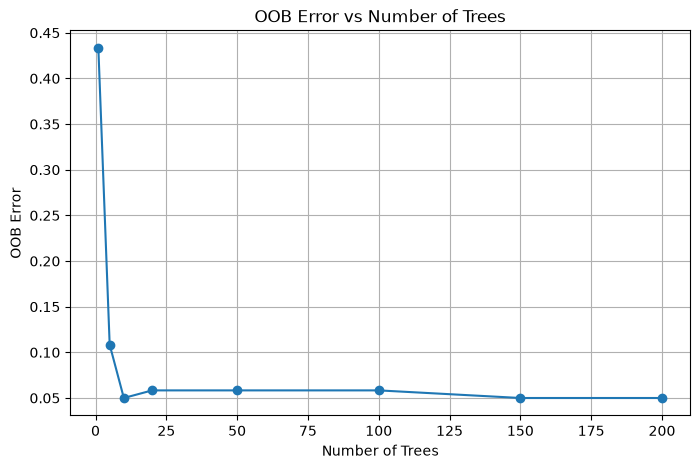

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(
    n_estimators_list,
    oob_errors,
    marker="o"
)
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("OOB Error vs Number of Trees")
plt.grid(True)
plt.show()

## 9. Feature Subsampling using `max_features`

In [17]:
max_features_values = [1, 2, 3, 4]
feature_results = []

for mf in max_features_values:
    rf_temp = RandomForestClassifier(
        n_estimators=100,
        max_features=mf,
        random_state=42,
        oob_score=True,
        bootstrap=True
    )

    rf_temp.fit(X_train, y_train)

    test_accuracy = accuracy_score(
        y_test,
        rf_temp.predict(X_test)
    )

    feature_results.append([
        mf,
        test_accuracy,
        rf_temp.oob_score_
    ])

feature_results_df = pd.DataFrame(
    feature_results,
    columns=["max_features", "Test Accuracy", "OOB Score"]
)

display(feature_results_df)

,max_features,Test Accuracy,OOB Score
0,1,0.933333,0.950000
1,2,0.900000,0.941667
2,3,0.933333,0.950000
3,4,0.966667,0.950000


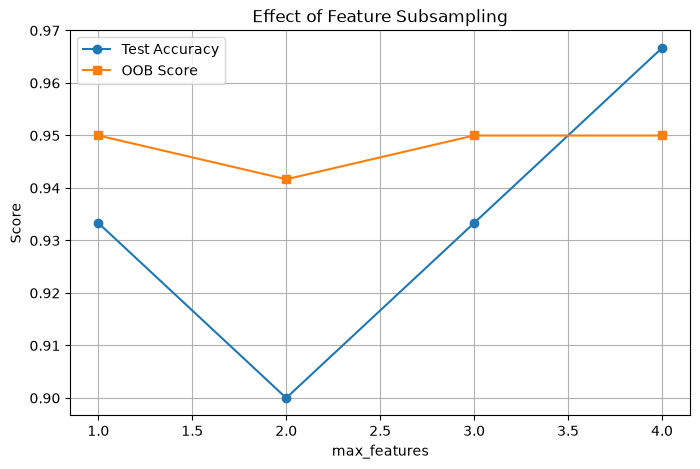

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    feature_results_df["max_features"],
    feature_results_df["Test Accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.plot(
    feature_results_df["max_features"],
    feature_results_df["OOB Score"],
    marker="s",
    label="OOB Score"
)

plt.xlabel("max_features")
plt.ylabel("Score")
plt.title("Effect of Feature Subsampling")
plt.legend()
plt.grid(True)
plt.show()

## 10. Manual Bootstrap Bagging

In [19]:
n_models = 10
bagging_predictions = []

for i in range(n_models):
    X_bootstrap, y_bootstrap = resample(
        X_train,
        y_train,
        replace=True,
        random_state=42 + i
    )

    model = DecisionTreeClassifier(
        random_state=42 + i
    )

    model.fit(X_bootstrap, y_bootstrap)
    predictions = model.predict(X_test)
    bagging_predictions.append(predictions)

bagging_predictions = np.array(bagging_predictions)

final_predictions = []

for j in range(X_test.shape[0]):
    votes = bagging_predictions[:, j]
    values, counts = np.unique(votes, return_counts=True)
    final_predictions.append(values[np.argmax(counts)])

final_predictions = np.array(final_predictions)

manual_bagging_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print("Manual Bagging Accuracy:", manual_bagging_accuracy)

Manual Bagging Accuracy: 0.9666666666666667


## 11. BaggingClassifier

In [20]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    bootstrap=True,
    random_state=42
)

bagging.fit(X_train, y_train)

y_pred_bagging = bagging.predict(X_test)

bagging_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)

print("BaggingClassifier Accuracy:", bagging_accuracy)

BaggingClassifier Accuracy: 0.9666666666666667


## 12. Permutation Feature Importance

In [21]:
result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
3,petal width (cm),0.176667
2,petal length (cm),0.166667
1,sepal width (cm),-0.033333
0,sepal length (cm),-0.056667


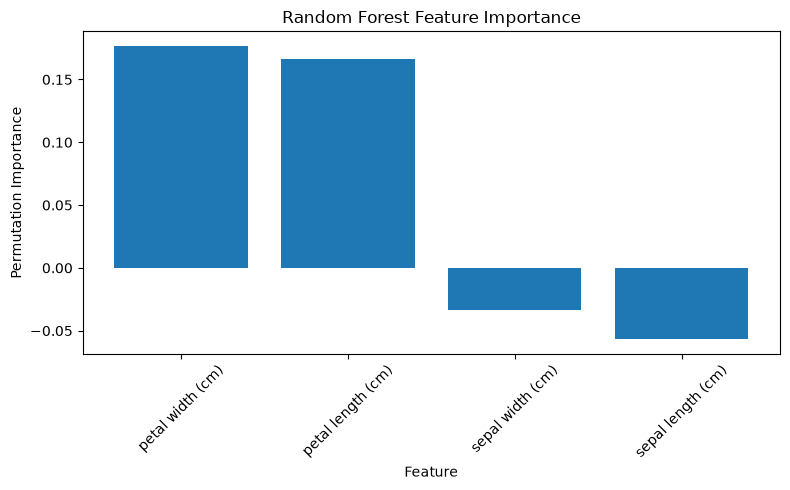

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Permutation Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Model Comparison

In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Manual Bagging",
        "BaggingClassifier",
        "Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        manual_bagging_accuracy,
        bagging_accuracy,
        rf_accuracy
    ]
})

display(comparison)

,Model,Accuracy
0,Decision Tree,0.933333
1,Manual Bagging,0.966667
2,BaggingClassifier,0.966667
3,Random Forest,0.900000


## 14. Random Forest Classification Report

In [24]:
print("Random Forest Classification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=iris.target_names
))

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

Random Forest Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


## Conclusion

The Iris dataset was used to study ensemble learning techniques.

A Decision Tree was trained as a baseline model. Random Forest was then implemented using multiple decision trees with bootstrap sampling and feature subsampling.

The Out-of-Bag (OOB) score and OOB error were calculated. The relationship between the number of trees and OOB error was also studied.

Feature subsampling was investigated using different values of `max_features`. Bagging was implemented manually using bootstrap samples and also using `BaggingClassifier`.

Finally, permutation feature importance was used to study the contribution of the Iris features to Random Forest predictions.